In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open('eo_qubit_results.pkl', 'rb') as f:
    payload = pickle.load(f)

meta    = payload['meta']
results = payload['results']

distances     = meta['distances']
p_mean_values = meta['p_mean_values']
sigma_frac    = meta['sigma_frac']
shots         = meta['shots']
Nkeep         = meta['Nkeep']
num_maps      = meta['num_maps']

print('Loaded results')
print(f'  distances     = {distances}')
print(f'  p_mean_values = {[float(f"{p:.4g}") for p in p_mean_values]}')
print(f'  shots         = {shots}')
print(f'  Nkeep         = {Nkeep}')
print(f'  sigma_frac    = {sigma_frac}')
print(f'  num_maps      = {num_maps}')
print(f'  axis model    = {meta["axis_model"]}')

Loaded results
  distances     = [3, 5]
  p_mean_values = [0.01, 0.01395, 0.01946, 0.02714, 0.03786, 0.05282, 0.07368, 0.1028, 0.1434, 0.2]
  shots         = 10000
  Nkeep         = 32
  sigma_frac    = 0.3
  num_maps      = 3
  axis model    = p_mean_z = p_mean_n = p_mean


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

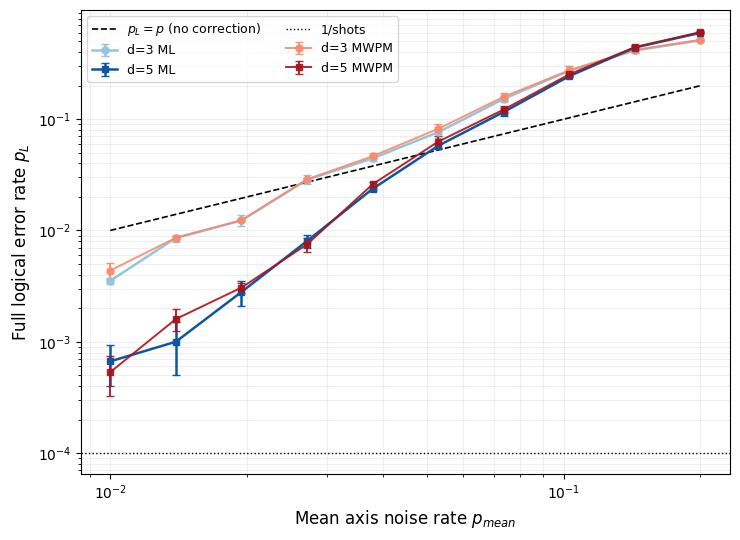

In [2]:
# Plot 1: ML vs MWPM — local EO qubit noise (full logical)
import matplotlib.cm as cm
import math

n = len(distances)
blue_colors = [cm.Blues(0.4 + 0.45 * i / max(n - 1, 1)) for i in range(n)]
red_colors  = [cm.Reds( 0.4 + 0.45 * i / max(n - 1, 1)) for i in range(n)]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(p_mean_values, p_mean_values, 'k--', linewidth=1.2, label='$p_L = p$ (no correction)')
ax.axhline(y=1/shots, color='k', linestyle=':', linewidth=1.0, label='1/shots')

types = ['o', 's', '^']
for i, d in enumerate(distances):
    r = results[d]
    ax.errorbar(
        p_mean_values, r['peps_local_mean'], yerr=r['peps_local_std'],
        fmt=types[i]+'-', color=blue_colors[i], markersize=5, linewidth=1.8, capsize=3,
        label=f'd={d} ML',
    )
    ax.errorbar(
        p_mean_values, r['mwpm_local_mean'], yerr=r['mwpm_local_std'],
        fmt=types[i]+'-', color=red_colors[i], markersize=5, linewidth=1.4, capsize=3, alpha=0.9,
        label=f'd={d} MWPM',
    )

handles, labels = ax.get_legend_handles_labels()
ncol = 2
nrow = math.ceil(len(handles) / ncol)
order = [(k % nrow) * ncol + (k // nrow) for k in range(len(handles))]
ax.legend([handles[i] for i in order], [labels[i] for i in order], fontsize=9, ncol=ncol)

ax.set_xlabel('Mean axis noise rate $p_{mean}$', fontsize=12)
ax.set_ylabel('Full logical error rate $p_L$', fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.savefig('eo_qubit_peps_vs_mwpm_local.png', dpi=160)
plt.show()

In [3]:
# Summary table
col_w = 12
header = f"{'p_mean':>10}" + ''.join(
    f"{'d='+str(d)+' PEPS':>{col_w}}{'d='+str(d)+' MWPM':>{col_w}}"
    for d in distances
)
print(header)
print('-' * len(header))
for i, p in enumerate(p_mean_values):
    row = f"{p:10.4f}" + ''.join(
        f"{results[d]['peps_local_mean'][i]:{col_w}.4f}"
        f"{results[d]['mwpm_local_mean'][i]:{col_w}.4f}"
        for d in distances
    )
    print(row)

    p_mean    d=3 PEPS    d=3 MWPM    d=5 PEPS    d=5 MWPM
----------------------------------------------------------
    0.0100      0.0035      0.0044      0.0007      0.0005
    0.0139      0.0086      0.0086      0.0010      0.0016
    0.0195      0.0123      0.0123      0.0028      0.0031
    0.0271      0.0285      0.0288      0.0080      0.0075
    0.0379      0.0445      0.0465      0.0236      0.0260
    0.0528      0.0763      0.0819      0.0577      0.0628
    0.0737      0.1522      0.1589      0.1161      0.1220
    0.1028      0.2729      0.2746      0.2436      0.2528
    0.1434      0.4143      0.4190      0.4400      0.4437
    0.2000      0.5105      0.5157      0.5968      0.6058
